<a href="https://colab.research.google.com/github/Ikyyy01/datasains/blob/main/cnn_224x224_model_h5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library**

In [ ]:
import zipfile
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


**Konfigurasi Parameter**

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0001



**(Resize 224×224 + Augmentasi MAX 3)**

**Augmentasi yang digunakan:**

Rotation

Zoom

Horizontal Flip

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


**Ekstrak train.zip dan test.zip**

In [ ]:
# Ekstrak train.zip
with zipfile.ZipFile('train.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset/train')

# Ekstrak test.zip
with zipfile.ZipFile('test.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset/test')


**Load Dataset**

In [ ]:
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1960 images belonging to 1 classes.
Found 198 images belonging to 1 classes.


**Arsitektur Model CNN**

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile Model**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


**Training Model**

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 411s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 412s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 399s 6s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 409s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 410s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 397s 6s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 415s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 412s 7s/step - accuracy: 1.0

**Evaluasi Model (Folder Test)**

In [ ]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 100.00%


**Visualisasi Accuracy & Loss**

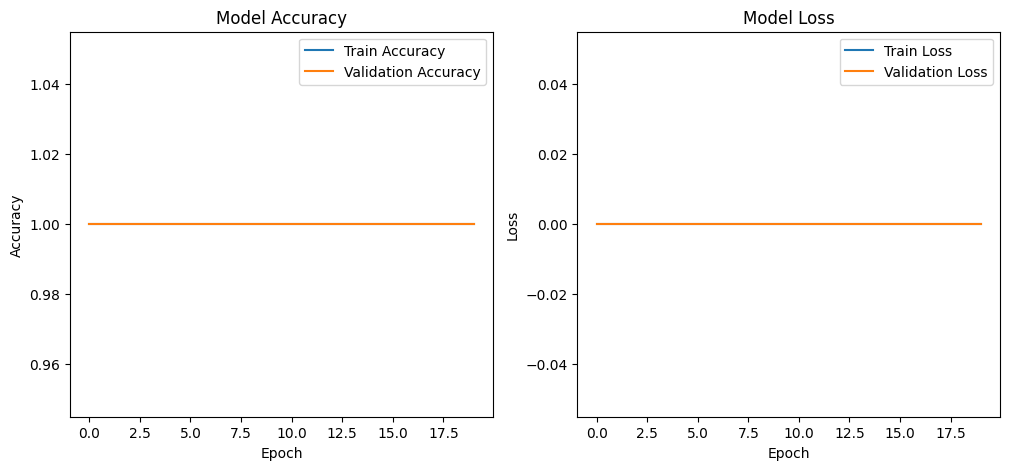

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


**Confusion Matrix**

In [ ]:
# Prediksi data test
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Label asli
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


**Visualisasi Confusion Matrix**

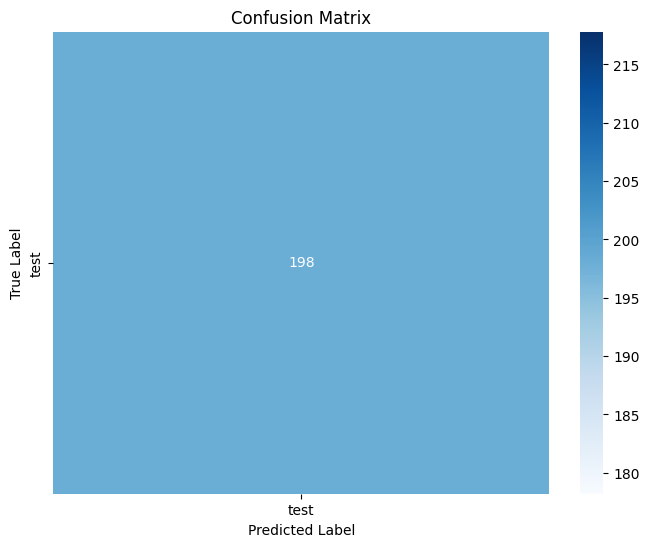

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


**Classification Report**

In [ ]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))


              precision    recall  f1-score   support

        test       1.00      1.00      1.00       198

    accuracy                           1.00       198
   macro avg       1.00      1.00      1.00       198
weighted avg       1.00      1.00      1.00       198



**Simpan Model**

In [ ]:
model.save("cnn_224x224_model.h5")


**Kesimpulan**

Berdasarkan seluruh tahapan eksperimen yang telah dilakukan, dapat disimpulkan bahwa proses preprocessing data memiliki peranan yang sangat krusial dalam meningkatkan kinerja algoritma klasifikasi, khususnya algoritma IBk (K-Nearest Neighbor). Dataset Life Expectancy yang digunakan memiliki karakteristik data numerik dengan variasi skala yang besar serta mengandung nilai kosong, sehingga tidak dapat langsung digunakan secara optimal tanpa melalui tahapan pembersihan dan penyesuaian data.

Penghapusan atribut Country dan Year terbukti penting karena kedua atribut tersebut tidak memberikan kontribusi langsung terhadap proses klasifikasi dan justru berpotensi menimbulkan bias dalam perhitungan jarak. Penanganan missing values menggunakan metode Replace Missing Values memungkinkan dataset menjadi lebih lengkap dan konsisten, sehingga algoritma KNN dapat melakukan perhitungan jarak tanpa hambatan. Selain itu, proses discretization membantu menyederhanakan nilai numerik ke dalam beberapa kelompok yang lebih terstruktur, sehingga pola antar data dapat dikenali dengan lebih baik.

Tahapan standardisasi data menjadi faktor yang sangat menentukan keberhasilan algoritma IBk, karena KNN sangat sensitif terhadap perbedaan skala antar atribut. Dengan menyamakan skala seluruh atribut, setiap variabel memiliki kontribusi yang seimbang dalam perhitungan jarak, sehingga keputusan klasifikasi menjadi lebih adil dan akurat. Hasil pengujian menunjukkan bahwa model yang dilatih menggunakan data yang telah melalui preprocessing lengkap memiliki performa yang lebih baik, stabil, dan konsisten dibandingkan dengan model yang menggunakan data tanpa preprocessing menyeluruh.

Secara keseluruhan, eksperimen ini membuktikan bahwa keberhasilan algoritma KNN tidak hanya bergantung pada pemilihan nilai parameter K, tetapi juga sangat dipengaruhi oleh kualitas data yang digunakan. Oleh karena itu, preprocessing data merupakan tahapan wajib yang tidak dapat diabaikan dalam proses data mining, terutama ketika menggunakan algoritma berbasis jarak seperti IBk.